In [1]:
%load_ext watermark


In [2]:
import itertools as it
import os

import matplotlib as mpl
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
from phyloframe import _auxlib as pfa
from phyloframe import legacy as pfl
from pyfonts import load_google_font
import seaborn as sns
from teeplot import teeplot as tp

import pylib


/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/alifedata_phyloinformatics_convert/_impl/phytrack_Systematcs.py:7: UserWarning: ImportWarning: phylotrackpy.Systematics import failed; inserting a no-op mock for Systematics. This is likely because phylotrackpy is not installed.
  warnings.warn(


In [3]:
%watermark -diwmuv -iv


Last updated: 2026-04-26T01:11:38.329821+00:00

Python implementation: CPython
Python version       : 3.11.15
IPython version      : 7.31.1

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.8.0-1044-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit

phyloframe: 0.6.1
pandas    : 2.2.3
numpy     : 2.1.2
teeplot   : 1.4.2
matplotlib: 3.10.0
pylib     : 0.0.0
seaborn   : 0.13.2

Watermark: 2.4.3



In [4]:
teeplot_subdir = os.environ.get(
    "NOTEBOOK_NAME", "2026-03-18-260225-btqc-lineage-sweep-s00-dsamp"
)
teeplot_subdir


'2026-03-18-260225-btqc-lineage-sweep-s00-dsamp'

In [5]:
pfa.seed_random(1)


In [6]:
font = load_google_font("Merriweather", weight=300)
mpl.font_manager.fontManager.addfont(font.get_file())
plt.rcParams["font.family"] = font.get_name()


## Prep Data


In [7]:
df_pure = pfl.alifestd_join_roots(
    pd.read_parquet("https://osf.io/5hm9z/download"),
)
df_pure


/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_join_roots performs update operations that do not update topology-dependent columns, which may be invalidated: ['num_children']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars} or set HSTRAT_ALIFESTD_WARN_TOPOLOGICAL_SENSITIVITY_SUPPRESS environment variable.
  warnings.warn(


,dstream_data_id,id,ancestor_id,dstream_rank,hstrat_differentia_bitwidth,dstream_S,data_hex,genomeFlavor,globalSeed,nCol,...,layer,layer_T,position,is_root,num_children,is_leaf,is_lineage,is_foliage,extant,is_oldest_root
0,9223372036854775807,0,0,0,1,64,None,NaN,NaN,NaN,...,NaN,NaN,NaN,True,2,False,False,False,False,True
1,9223372036854775807,1,0,2046,1,64,None,NaN,NaN,NaN,...,NaN,NaN,NaN,False,2,False,False,False,False,False
2,9223372036854775807,2,1,15870,1,64,None,NaN,NaN,NaN,...,NaN,NaN,NaN,False,2,False,False,False,False,False
3,9223372036854775807,3,2,16287,1,64,None,NaN,NaN,NaN,...,NaN,NaN,NaN,False,2,False,False,False,False,False
4,9223372036854775807,4,3,16383,1,64,None,NaN,NaN,NaN,...,NaN,NaN,NaN,False,2,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1588331,9223372036854775807,1671465693,1671465692,147917,1,64,None,NaN,NaN,NaN,...,NaN,NaN,NaN,False,2,False,False,False,False,False
1588332,999994957,1671465899,1671465693,147918,1,64,c9478920000241cfdfb716bb197183c6004831cc,genome_purifyingsweep,2.0,755.0,...,1249.0,9873.0,878307.0,False,0,True,False,True,True,False
1588333,999522942,1671467778,1671429847,147919,1,64,c9477030000241d0dfb7163b5771b6de004831e4,genome_purifyingsweep,2.0,755.0,...,1249.0,9873.0,406292.0,False,0,True,False,True,True,False
1588334,9223372036854775807,1671472379,1671451302,147919,1,64,None,NaN,NaN,NaN,...,NaN,NaN,NaN,False,3,False,False,False,False,False


In [8]:
df_pure = (
    df_pure.pipe(pfl.alifestd_to_working_format)
    .pipe(pfl.alifestd_collapse_unifurcations)
    .pipe(pfl.alifestd_to_working_format)
)
df_pure


/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_collapse_unifurcations performs delete/update operations that do not update topology-dependent columns, which may be invalidated: ['num_children']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars} or set HSTRAT_ALIFESTD_WARN_TOPOLOGICAL_SENSITIVITY_SUPPRESS environment variable.
  warnings.warn(


,dstream_data_id,id,ancestor_id,dstream_rank,hstrat_differentia_bitwidth,dstream_S,data_hex,genomeFlavor,globalSeed,nCol,...,layer,layer_T,position,is_root,num_children,is_leaf,is_lineage,is_foliage,extant,is_oldest_root
0,9223372036854775807,0,0,0,1,64,None,NaN,NaN,NaN,...,NaN,NaN,NaN,True,2,False,False,False,False,True
1,9223372036854775807,1,0,2046,1,64,None,NaN,NaN,NaN,...,NaN,NaN,NaN,False,2,False,False,False,False,False
2,9223372036854775807,2,1,15870,1,64,None,NaN,NaN,NaN,...,NaN,NaN,NaN,False,2,False,False,False,False,False
3,9223372036854775807,3,2,16287,1,64,None,NaN,NaN,NaN,...,NaN,NaN,NaN,False,2,False,False,False,False,False
4,9223372036854775807,4,3,16383,1,64,None,NaN,NaN,NaN,...,NaN,NaN,NaN,False,2,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1588313,999781405,101876,101626,147915,1,64,c94779c0000241ccdfb756bb93f5af0600483167,genome_purifyingsweep,2.0,755.0,...,1249.0,9873.0,664755.0,False,0,True,False,True,True,False
1588316,999474648,101877,101308,147916,1,64,c94773c0000241cddfb7563b5f759e5e004831a0,genome_purifyingsweep,2.0,755.0,...,1249.0,9873.0,357998.0,False,0,True,False,True,True,False
1588332,999994957,101878,101837,147918,1,64,c9478920000241cfdfb716bb197183c6004831cc,genome_purifyingsweep,2.0,755.0,...,1249.0,9873.0,878307.0,False,0,True,False,True,True,False
1588333,999522942,101879,101601,147919,1,64,c9477030000241d0dfb7163b5771b6de004831e4,genome_purifyingsweep,2.0,755.0,...,1249.0,9873.0,406292.0,False,0,True,False,True,True,False


In [9]:
df_pure["x"] = df_pure["position"] // df_pure["nCol"]
df_pure["x_"] = df_pure["x"] / df_pure["nRow"]
df_pure["y"] = df_pure["position"] % df_pure["nCol"]
df_pure["y_"] = df_pure["y"] / df_pure["nCol"]

df_pure["origin_time"] = df_pure["dstream_rank"]


In [10]:
df_pure_lineage = df_pure.copy()
df_pure_lineage["extant"] = df_pure["is_lineage"]
df_pure_lineage = pfl.alifestd_prune_extinct_lineages_asexual(df_pure_lineage)
df_pure_lineage


/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_prune_extinct_lineages_asexual performs delete operations that do not update topology-dependent columns, which may be invalidated: ['num_children']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars} or set HSTRAT_ALIFESTD_WARN_TOPOLOGICAL_SENSITIVITY_SUPPRESS environment variable.
  warnings.warn(


,dstream_data_id,id,ancestor_id,dstream_rank,hstrat_differentia_bitwidth,dstream_S,data_hex,genomeFlavor,globalSeed,nCol,...,is_leaf,is_lineage,is_foliage,extant,is_oldest_root,x,x_,y,y_,origin_time
0,9223372036854775807,0,0,0,1,64,None,NaN,NaN,NaN,...,False,False,False,False,True,NaN,NaN,NaN,NaN,0
1,9223372036854775807,1,0,2046,1,64,None,NaN,NaN,NaN,...,False,False,False,False,False,NaN,NaN,NaN,NaN,2046
2,9223372036854775807,2,1,15870,1,64,None,NaN,NaN,NaN,...,False,False,False,False,False,NaN,NaN,NaN,NaN,15870
3,9223372036854775807,3,2,16287,1,64,None,NaN,NaN,NaN,...,False,False,False,False,False,NaN,NaN,NaN,NaN,16287
4,9223372036854775807,4,3,16383,1,64,None,NaN,NaN,NaN,...,False,False,False,False,False,NaN,NaN,NaN,NaN,16383
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3052,9223372036854775807,101749,101683,147679,1,64,None,NaN,NaN,NaN,...,False,False,False,False,False,NaN,NaN,NaN,NaN,147679
3053,997368639,101750,101749,147685,1,64,c94740f0000240e6dfb7563bdf598d9e004814bc,genome_purifyingsweep,2.0,755.0,...,True,True,False,True,False,24.0,0.020513,569.0,0.753642,147685
3054,9223372036854775807,101809,101749,147775,1,64,None,NaN,NaN,NaN,...,False,False,False,False,False,NaN,NaN,NaN,NaN,147775
3055,998234703,101810,101809,147791,1,64,c9476b0000024150dfb7563bce59bd9e00482200,genome_purifyingsweep,2.0,755.0,...,True,True,False,True,False,1.0,0.000855,648.0,0.858278,147791


In [11]:
df_pure_with_foliage = df_pure.copy()
df_pure_with_foliage["extant"] = (
    df_pure["is_foliage"] & (np.random.rand(len(df_pure)) < 0.03)
) | df_pure["is_lineage"]
df_pure_with_foliage = pfl.alifestd_prune_extinct_lineages_asexual(
    df_pure_with_foliage
)
df_pure_with_foliage


/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_prune_extinct_lineages_asexual performs delete operations that do not update topology-dependent columns, which may be invalidated: ['num_children']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars} or set HSTRAT_ALIFESTD_WARN_TOPOLOGICAL_SENSITIVITY_SUPPRESS environment variable.
  warnings.warn(


,dstream_data_id,id,ancestor_id,dstream_rank,hstrat_differentia_bitwidth,dstream_S,data_hex,genomeFlavor,globalSeed,nCol,...,is_leaf,is_lineage,is_foliage,extant,is_oldest_root,x,x_,y,y_,origin_time
0,9223372036854775807,0,0,0,1,64,None,NaN,NaN,NaN,...,False,False,False,False,True,NaN,NaN,NaN,NaN,0
1,9223372036854775807,1,0,2046,1,64,None,NaN,NaN,NaN,...,False,False,False,False,False,NaN,NaN,NaN,NaN,2046
2,9223372036854775807,2,1,15870,1,64,None,NaN,NaN,NaN,...,False,False,False,False,False,NaN,NaN,NaN,NaN,15870
3,9223372036854775807,3,2,16287,1,64,None,NaN,NaN,NaN,...,False,False,False,False,False,NaN,NaN,NaN,NaN,16287
4,9223372036854775807,4,3,16383,1,64,None,NaN,NaN,NaN,...,False,False,False,False,False,NaN,NaN,NaN,NaN,16383
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19010,998234703,101810,101809,147791,1,64,c9476b0000024150dfb7563bce59bd9e00482200,genome_purifyingsweep,2.0,755.0,...,True,True,False,True,False,1.0,0.000855,648.0,0.858278,147791
19011,998334461,101826,101192,147800,1,64,c947662000024159dfb7163b865da85e00482320,genome_purifyingsweep,2.0,755.0,...,True,False,True,True,False,133.0,0.113675,746.0,0.988079,147800
19012,999874742,101841,101797,147885,1,64,c9478bb0000241aedfb7163b32b180be00482dab,genome_purifyingsweep,2.0,755.0,...,True,False,True,True,False,1004.0,0.858120,72.0,0.095364,147885
19013,999139964,101854,101809,147901,1,64,c9479010000241bedfb7563be659a89e00482fa8,genome_purifyingsweep,2.0,755.0,...,True,True,False,True,False,30.0,0.025641,664.0,0.879470,147901


## Plot Lineage Tree


/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_prune_extinct_lineages_asexual performs delete operations that do not update topology-dependent columns, which may be invalidated: ['num_children']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars} or set HSTRAT_ALIFESTD_WARN_TOPOLOGICAL_SENSITIVITY_SUPPRESS environment variable.
  warnings.warn(
/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_downsample_tips_lineage_asexual performs delete operations that do not update topology-dependent columns, which may be invalidated: ['num_children']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_p

teeplots/2026-03-18-260225-btqc-lineage-sweep-s00-dsamp/layout=vertical+regime=pure+seed=0+viz=draw-ctree+x=x+y=y+ext=.pdf
teeplots/2026-03-18-260225-btqc-lineage-sweep-s00-dsamp/layout=vertical+regime=pure+seed=0+viz=draw-ctree+x=x+y=y+ext=.png


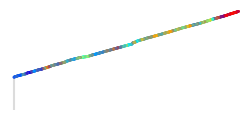

/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_prune_extinct_lineages_asexual performs delete operations that do not update topology-dependent columns, which may be invalidated: ['num_children']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars} or set HSTRAT_ALIFESTD_WARN_TOPOLOGICAL_SENSITIVITY_SUPPRESS environment variable.
  warnings.warn(
/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_collapse_unifurcations performs delete/update operations that do not update topology-dependent columns, which may be invalidated: ['num_children']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_pol

teeplots/2026-03-18-260225-btqc-lineage-sweep-s00-dsamp/invert=y+layout=vertical+regime=pure-mask+seed=0+viz=draw-ctree+x=x+y=y+ext=.pdf
teeplots/2026-03-18-260225-btqc-lineage-sweep-s00-dsamp/invert=y+layout=vertical+regime=pure-mask+seed=0+viz=draw-ctree+x=x+y=y+ext=.png


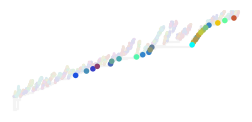

/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_collapse_unifurcations performs delete/update operations that do not update topology-dependent columns, which may be invalidated: ['num_children', 'node_depth']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars} or set HSTRAT_ALIFESTD_WARN_TOPOLOGICAL_SENSITIVITY_SUPPRESS environment variable.
  warnings.warn(
/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_collapse_unifurcations performs delete/update operations that do not update topology-dependent columns, which may be invalidated: ['num_children', 'node_depth']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_t

teeplots/2026-03-18-260225-btqc-lineage-sweep-s00-dsamp/invert=xy+layout=vertical+regime=pure-mask+seed=0+viz=draw-ctree+x=x+y=y+ext=.pdf
teeplots/2026-03-18-260225-btqc-lineage-sweep-s00-dsamp/invert=xy+layout=vertical+regime=pure-mask+seed=0+viz=draw-ctree+x=x+y=y+ext=.png


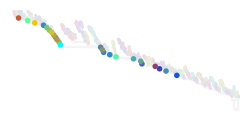

teeplots/2026-03-18-260225-btqc-lineage-sweep-s00-dsamp/cmap=bcyr+regime=pure+seed=0+viz=draw-cscatter+x=x+y=y+ext=.pdf
teeplots/2026-03-18-260225-btqc-lineage-sweep-s00-dsamp/cmap=bcyr+regime=pure+seed=0+viz=draw-cscatter+x=x+y=y+ext=.png


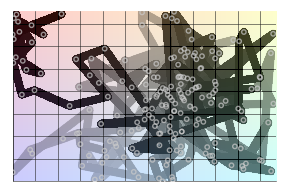

In [12]:
for regime, seed in it.product(
    ("pure",),
    range(1),
):
    df = df_pure_lineage.copy()
    df["extant"] = df["origin_time"] > df["origin_time"].max() / 3
    df = (
        df.pipe(pfl.alifestd_prune_extinct_lineages_asexual)
        .pipe(pfl.alifestd_to_working_format)
        .pipe(
            pfl.alifestd_downsample_tips_lineage_asexual,
            criterion_target="layer",
            n_downsample=800,
            seed=seed,
        )
        .pipe(pfl.alifestd_collapse_unifurcations)
        .pipe(pfl.alifestd_delete_unifurcating_roots_asexual)
        .pipe(pfl.alifestd_mark_node_depth_asexual)
    )

    for layout in ("vertical",):
        with tp.teed(
            pylib.chloropleth.draw_ctree,
            df,
            x="x_",
            y="y_",
            cmap=pylib.cmap.bcyr.get_color,
            layout=layout,
            scatter_kws=dict(
                edgecolor="none",
                s=4,
            ),
            scatter_shuffle=1,
            tree_kws=dict(
                edge=dict(
                    color="gainsboro",
                    linewidth=0.5,
                ),
                margins=-0.05,
            ),
            teeplot_outattrs={"regime": regime, "seed": seed},
            teeplot_subdir=teeplot_subdir,
        ) as teed:
            teed.invert_yaxis()
            teed.figure.set_size_inches(3, 1.33)

    ####
    df_ = df_pure_with_foliage.copy()
    df_["x__"] = df_["x_"].copy()
    df_["y__"] = df_["y_"].copy()

    mask = df_["dstream_data_id"].isin(df["dstream_data_id"])
    df_.loc[~mask, "x_"] = pd.NA
    df_.loc[~mask, "y_"] = pd.NA

    df_["extant"] = df_["is_foliage"] | (
        df_["is_lineage"] & (df_["layer"] % 33 == 0)
    )
    # df_["extant"] &= (np.random.rand(len(df_)) < 0.5)
    df_ = (
        df_.pipe(pfl.alifestd_prune_extinct_lineages_asexual)
        .pipe(pfl.alifestd_to_working_format)
        .pipe(pfl.alifestd_collapse_unifurcations)
        .pipe(pfl.alifestd_mark_node_depth_asexual)
    )

    for layout, invert in it.product(
        ("vertical",),
        ("y", "xy"),
    ):
        with tp.teed(
            pylib.chloropleth.draw_ctree,
            df_,
            x="x__",
            y="y__",
            cmap=lambda *args, **kwargs: sns.set_hls_values(
                pylib.cmap.bcyr.get_color(*args, **kwargs),
                l=0.9,
                s=0.4,
            ),
            layout=layout,
            scatter_kws=dict(
                edgecolor="none",
                s=4,
            ),
            scatter_shuffle=1,
            tree_kws=dict(
                edge=dict(
                    color="#f4f4f4",
                    linewidth=0.5,
                ),
                margins=-0.05,
            ),
            teeplot_outattrs={
                "invert": invert,
                "regime": f"{regime}-mask",
                "seed": seed,
            },
            teeplot_subdir=teeplot_subdir,
        ) as teed:
            pylib.chloropleth.draw_ctree(
                df_,
                x="x_",
                y="y_",
                cmap=pylib.cmap.bcyr.get_color,
                layout=layout,
                scatter_kws=dict(
                    edgecolor="none",
                    s=16,
                ),
                scatter_shuffle=1,
                tree_kws=dict(
                    edge=dict(
                        alpha=0.0,
                        color="#f4f4f4",
                        linewidth=0.5,
                    ),
                    margins=-0.05,
                ),
            )
            teed.figure.set_size_inches(3, 1.33)
            if "x" in invert:
                teed.invert_xaxis()
            if "y" in invert:
                teed.invert_yaxis()
    ####

    data = df.copy().sort_values(by="node_depth").dropna(subset=["x_", "y_"])
    data = data[data["is_leaf"]].copy()
    data = data.reset_index(drop=True).copy()
    data.index = pd.to_timedelta(data["origin_time"], unit="s")
    data = data.resample("500s").nearest().copy()
    with tp.teed(
        pylib.chloropleth.draw_cscatter,
        data,
        x="x",
        y="y",
        cmap=pylib.cmap.bcyr.get_color,
        despine=True,
        major=100,
        minor=None,
        xmax=1170,
        ymax=755,
        scatter_kws=dict(
            alpha=0.7,
            color="none",
            edgecolor="white",
            linewidth=1,
            linestyle="-",
            marker="o",
            s=10,
            zorder=120,
        ),
        teeplot_outattrs={
            "cmap": "bcyr",
            "regime": regime,
            "seed": seed,
        },
        teeplot_subdir=teeplot_subdir,
    ) as teed:
        for i in range(len(data)):
            teed.plot(
                data["x"][i:],
                data["y"][i:],
                alpha=1 / len(data),
                color="black",
                lw=6,
            )
        teed.plot(
            data["x"],
            data["y"],
            alpha=0.2,
            color="black",
            lw=6,
            zorder=150,
        )
        teed.set_xlabel(None)
        teed.set_ylabel(None)
        teed.set_aspect("equal")
        fig = teed.figure
        fig.set_size_inches(3, 2)
        fig.tight_layout()


## Combined Plots


/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_collapse_unifurcations performs delete/update operations that do not update topology-dependent columns, which may be invalidated: ['num_children', 'node_depth']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars} or set HSTRAT_ALIFESTD_WARN_TOPOLOGICAL_SENSITIVITY_SUPPRESS environment variable.
  warnings.warn(
/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_collapse_unifurcations performs delete/update operations that do not update topology-dependent columns, which may be invalidated: ['num_children', 'node_depth']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_t

teeplots/2026-03-18-260225-btqc-lineage-sweep-s00-dsamp/s=4+viz=subplots+ext=.pdf
teeplots/2026-03-18-260225-btqc-lineage-sweep-s00-dsamp/s=4+viz=subplots+ext=.png


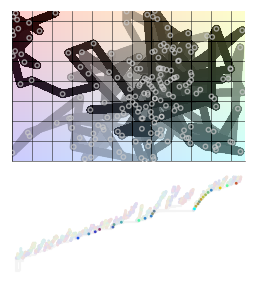

/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_collapse_unifurcations performs delete/update operations that do not update topology-dependent columns, which may be invalidated: ['num_children', 'node_depth']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars} or set HSTRAT_ALIFESTD_WARN_TOPOLOGICAL_SENSITIVITY_SUPPRESS environment variable.
  warnings.warn(
/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_collapse_unifurcations performs delete/update operations that do not update topology-dependent columns, which may be invalidated: ['num_children', 'node_depth']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_t

teeplots/2026-03-18-260225-btqc-lineage-sweep-s00-dsamp/s=16+viz=subplots+ext=.pdf
teeplots/2026-03-18-260225-btqc-lineage-sweep-s00-dsamp/s=16+viz=subplots+ext=.png


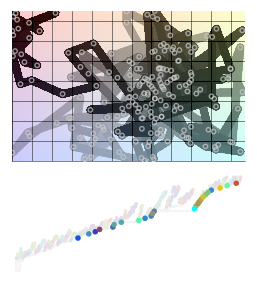

In [13]:
for s in (4, 16):
    with tp.teed(
        plt.subplots,
        ncols=1,
        nrows=2,
        figsize=(3, 4),
        gridspec_kw={"height_ratios": [2, 1], "hspace": 0.1, "wspace": 0.05},
        teeplot_outattrs={"s": s},
        teeplot_subdir=teeplot_subdir,
    ) as fig:
        fig, axs = fig

        for regime in ("pure",):
            pylib.chloropleth.draw_cscatter(
                data,
                x="x",
                y="y",
                ax=axs[0],
                cmap=pylib.cmap.bcyr.get_color,
                despine=True,
                major=100,
                minor=None,
                xmax=1170,
                ymax=755,
                scatter_kws=dict(
                    alpha=0.7,
                    color="none",
                    edgecolor="white",
                    linewidth=1,
                    linestyle="-",
                    marker="o",
                    s=10,
                    zorder=120,
                ),
            )
            for i in range(len(data)):
                axs[0].plot(
                    data["x"][i:],
                    data["y"][i:],
                    alpha=1 / len(data),
                    color="black",
                    lw=6,
                )
            axs[0].plot(
                data["x"],
                data["y"],
                alpha=0.2,
                color="black",
                lw=6,
                zorder=150,
            )
            axs[0].set_xlabel(None)
            axs[0].set_ylabel(None)
            axs[0].set_aspect("equal", anchor="S")

            pylib.chloropleth.draw_ctree(
                df_,
                x="x__",
                y="y__",
                ax=axs[1],
                cmap=lambda *args, **kwargs: sns.set_hls_values(
                    pylib.cmap.bcyr.get_color(*args, **kwargs),
                    l=0.9,
                    s=0.4,
                ),
                layout=layout,
                scatter_kws=dict(
                    edgecolor="none",
                    s=4,
                ),
                scatter_shuffle=1,
                tree_kws=dict(
                    edge=dict(
                        color="#f4f4f4",
                        linewidth=0.5,
                    ),
                    margins=-0.05,
                ),
            )
            pylib.chloropleth.draw_ctree(
                df_,
                x="x_",
                y="y_",
                ax=axs[1],
                cmap=pylib.cmap.bcyr.get_color,
                layout=layout,
                scatter_kws=dict(
                    edgecolor="none",
                    s=s,
                ),
                scatter_shuffle=1,
                tree_kws=dict(
                    edge=dict(
                        alpha=0.0,
                        color="#f4f4f4",
                        linewidth=0.5,
                    ),
                    margins=-0.05,
                ),
            )
            axs[1].invert_yaxis()
            axs[1].set_anchor("N")


In [14]:
import pymupdf

spatial_positions_path = (
    "assets/2026-03-04-wse-spatial-phylo-singleton-positions.pdf"
)
spatial_template_path = (
    "assets/2026-03-04-wse-spatial-phylo-singleton-template.pdf"
)

spatial_positions_doc = pymupdf.open(spatial_positions_path)
print(
    f"Positions: {len(spatial_positions_doc)} page(s), size {spatial_positions_doc[0].rect}"
)

spatial_template_doc = pymupdf.open(spatial_template_path)
print(
    f"Template:  {len(spatial_template_doc)} page(s), size {spatial_template_doc[0].rect}"
)


Positions: 1 page(s), size Rect(0.0, 0.0, 413.5670471191406, 279.6712341308594)
Template:  1 page(s), size Rect(0.0, 0.0, 413.5670471191406, 279.6712341308594)


In [15]:
spatial_target_colors = {
    # "accede": "#ACCEDE",
    "beefed": "#BEEFED",
    # "decade": "#DECADE",
    "deadbe": "#DEADBE",
}


def hex_to_rgb_float(hex_color):
    h = hex_color.lstrip("#")
    return tuple(int(h[i : i + 2], 16) / 255.0 for i in (0, 2, 4))


def find_rects_by_color(page, hex_color, tol=2 / 255):
    target = hex_to_rgb_float(hex_color)
    rects = []
    for path in page.get_drawings():
        fill = path.get("fill")
        if fill is None or len(fill) != 3:
            continue
        if all(abs(fill[i] - target[i]) < tol for i in range(3)):
            rects.append(path["rect"])
    return rects


spatial_positions_page = spatial_positions_doc[0]
spatial_color_rects = {}
for name, hex_color in spatial_target_colors.items():
    rects = find_rects_by_color(spatial_positions_page, hex_color)
    spatial_color_rects[name] = rects
    for r in rects:
        print(f"  {name} ({hex_color}): {r}")

spatial_positions_doc.close()


  beefed (#BEEFED): Rect(161.38299560546875, 23.645000457763672, 382.25, 169.08599853515625)
  deadbe (#DEADBE): Rect(161.87899780273438, 168.78900146484375, 382.7460021972656, 279.6719970703125)


In [16]:
spatial_plot_paths = {
    # "accede": "cmap=bcyr+regime=pure+seed=0+viz=draw-cscatter+x=x+y=y+ext=.pdf",
    "beefed": "cmap=bcyr+regime=pure+seed=0+viz=draw-cscatter+x=x+y=y+ext=.pdf",
    # "decade": "layout=vertical+regime=pure-mask+seed=0+viz=draw-ctree+x=x+y=y+ext=.pdf",
    "deadbe": "invert=xy+layout=vertical+regime=pure-mask+seed=0+viz=draw-ctree+x=x+y=y+ext=.pdf",
}

spatial_plot_docs = {}
for name, filename in spatial_plot_paths.items():
    path = os.path.join("teeplots", teeplot_subdir, filename)
    print(f"Loading {name} from: {path}")
    spatial_plot_docs[name] = pymupdf.open(path)

page = spatial_template_doc[0]
for name, rects in spatial_color_rects.items():
    src_doc = spatial_plot_docs[name]
    delta = {
        "accede": 11,
        "beefed": 11,
        "decade": 5,
        "deadbe": 5,
    }[name]
    for rect in rects:
        rect.y0 -= delta + 7 * name.startswith("de")
        rect.x0 -= delta
        rect.y1 += delta - 7 * name.startswith("de")
        rect.x1 += delta
        page.show_pdf_page(rect, src_doc, 0)
        print(f"  Inserted {name} at {rect}")

# set Interpolate on all raster images so PDF viewers use smooth scaling
for img in page.get_images(full=True):
    xref = img[0]
    if "/Interpolate" not in spatial_template_doc.xref_object(xref):
        spatial_template_doc.xref_set_key(xref, "Interpolate", "true")

spatial_output_destination = f"teeplots/{teeplot_subdir}/"
os.makedirs(spatial_output_destination, exist_ok=True)
spatial_output_path = os.path.join(
    spatial_output_destination,
    "wse-spatial-singleton-phylo-filled.pdf",
)
spatial_template_doc.save(spatial_output_path, garbage=4, deflate=True)
spatial_template_doc.close()
for d in spatial_plot_docs.values():
    d.close()
print(f"\nSaved to {spatial_output_path}")


Loading beefed from: teeplots/2026-03-18-260225-btqc-lineage-sweep-s00-dsamp/cmap=bcyr+regime=pure+seed=0+viz=draw-cscatter+x=x+y=y+ext=.pdf
Loading deadbe from: teeplots/2026-03-18-260225-btqc-lineage-sweep-s00-dsamp/invert=xy+layout=vertical+regime=pure-mask+seed=0+viz=draw-ctree+x=x+y=y+ext=.pdf
  Inserted beefed at Rect(150.38299560546875, 12.645000457763672, 393.25, 180.08599853515625)
  Inserted deadbe at Rect(156.87899780273438, 156.78900146484375, 387.7460021972656, 277.6719970703125)

Saved to teeplots/2026-03-18-260225-btqc-lineage-sweep-s00-dsamp/wse-spatial-singleton-phylo-filled.pdf


In [17]:
spatial_filled_doc = pymupdf.open(spatial_output_path)
dpi = 600
mat = pymupdf.Matrix(dpi / 72, dpi / 72)
pix = spatial_filled_doc[0].get_pixmap(matrix=mat, alpha=False)
spatial_png_path = spatial_output_path.replace(".pdf", ".png")
pix.save(spatial_png_path)
spatial_filled_doc.close()
print(f"Saved {pix.width}x{pix.height} @ {dpi} DPI to {spatial_png_path}")


Saved 3447x2331 @ 600 DPI to teeplots/2026-03-18-260225-btqc-lineage-sweep-s00-dsamp/wse-spatial-singleton-phylo-filled.png
